In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("./image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

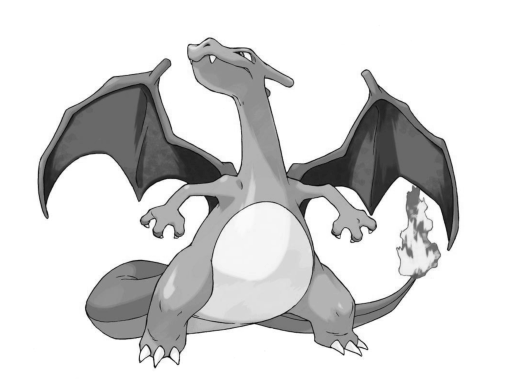

In [3]:
plt.imshow(image, cmap="gray")
plt.axis('off')
plt.show()

In [16]:
mask = np.array([[1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1]])

In [17]:
dialated_image = cv2.dilate(image, mask, iterations=1)
eroded_image = cv2.erode(image, mask, iterations=1)

opening_image = cv2.dilate(cv2.erode(image, mask, iterations=1), mask, iterations=1)
closing_image = cv2.erode(cv2.dilate(image, mask, iterations=1), mask, iterations=1)

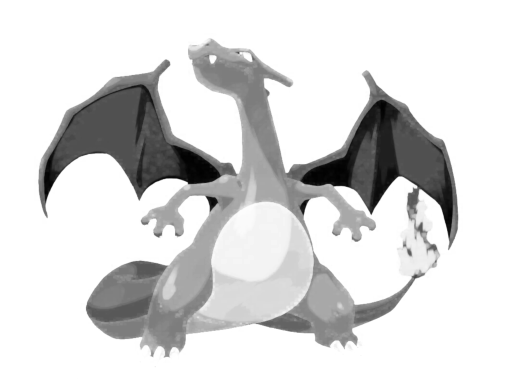

In [18]:
plt.imshow(dialated_image, cmap="gray")
plt.axis('off')
plt.show()

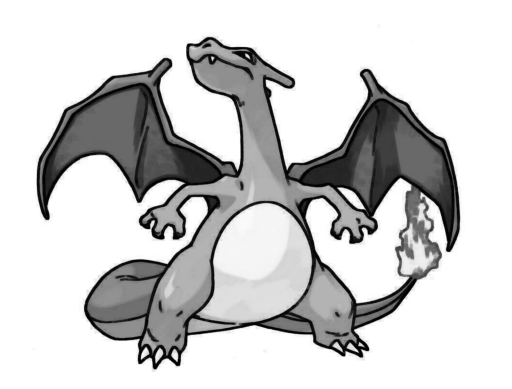

In [19]:
plt.imshow(eroded_image, cmap="gray")
plt.axis('off')
plt.show()

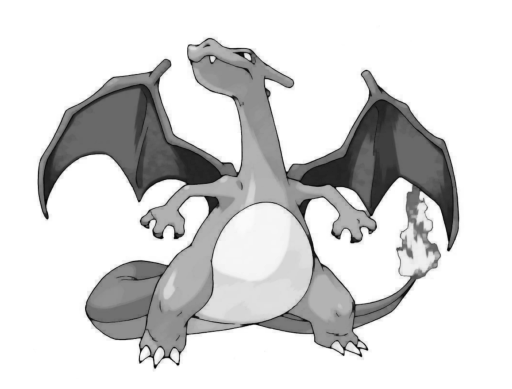

In [20]:
plt.imshow(opening_image, cmap="gray")
plt.axis('off')
plt.show()

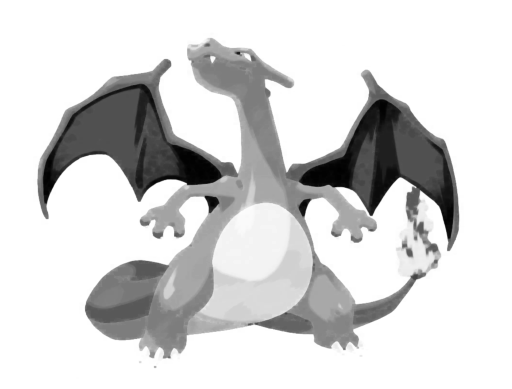

In [21]:
plt.imshow(closing_image, cmap="gray")
plt.axis('off')
plt.show()

In [22]:
def apply_mask(image, mask):
    filtered_image = np.zeros_like(image)
    height, width = image.shape
    for i in range(1, height - 1):
        for j in range(1, width - 1):
            region = image[i-1:i+2, j-1:j+2]
            value = np.sum(region * mask)
            filtered_image[i, j] = np.clip(value, 0, 255)
    return filtered_image

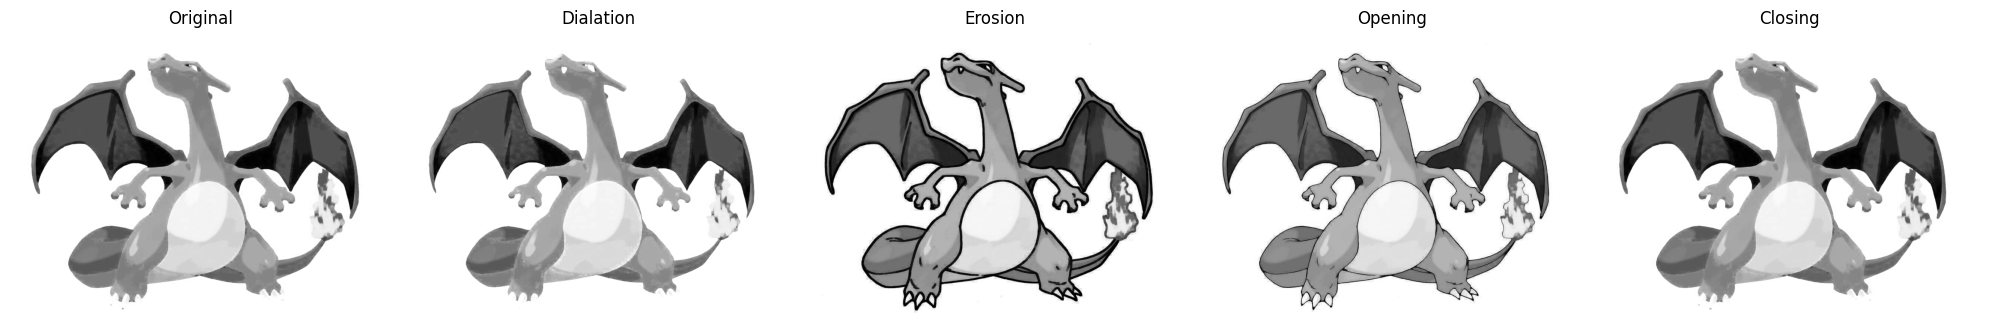

In [33]:
images = [image, dialated_image, eroded_image, opening_image, closing_image]
title = ["Original", "Dialation", "Erosion", "Opening", "Closing"]

fig, axes = plt.subplots(1, 5, figsize=(20, 15))

for ax, image, title in zip(axes, images, title):
    ax.imshow(image, cmap="gray")
    ax.axis('off')
    ax.set_title(title)
plt.tight_layout()